# Bank Marketing: Predicting Term Deposit Subscription

This project compares different classification models for predicting whether a bank client will subscribe to a term deposit following a marketing campaign.

The dataset contains 41,188 client records from direct marketing 
campaigns conducted by a Portuguese banking institution, released to 
the UCI Machine Learning Repository by Moro, Cortez & Rita (2014).

Note: the paper's own results were run on a larger, separate dataset 
(52,944 records, 2008–2013) with a different feature set - this 
project uses the smaller public release, not the exact data analyzed 
in the original paper.

The objective is to identify clients with a higher probability of 
subscription, using only information that would genuinely be 
available before deciding to make a call: the client's demographic 
and financial profile, their history with previous campaigns, and 
the broader economic conditions at that point in time.

## Data Leakage

A key modeling decision is the removal of the `duration` feature, which records the length of the current marketing call.

Although `duration` is known to be strongly associated with subscription outcome —
per the dataset documentation, calls with very short duration essentially never
result in a subscription — it is only known after the call has taken place. Since
the goal is to identify promising clients before contacting them, using this
feature would introduce data leakage and make the reported performance
unrealistically high.

For that reason, `duration` is excluded from every model in the comparison.

## Class Imbalance and Metric Choice

The target variable is highly imbalanced: approximately 88.7% of clients did not subscribe, and approximately 11.3% subscribed.

This means accuracy alone is not an appropriate measure of model quality. A classifier predicting every client as a non-subscriber would already achieve about 89% accuracy while providing no practical value — it would never identify a single subscriber.

Beyond accuracy, the choice of evaluation metric also has to reflect the *cost* of different errors, and those costs are not symmetric here:

* **A false negative** — a client who would have subscribed, but the model doesn't flag them — is a **missed sale**. That client is never called, and the opportunity is lost entirely.
* **A false positive** — a client who wouldn't subscribe, but the model flags them anyway — costs a few minutes of a call center agent's time. Low cost, easily absorbed.

Because a missed subscriber is far more costly to the business than a wasted call, this project treats **recall as more important than precision**, and uses **F2-score** — which weights recall twice as heavily as precision — as the primary model selection metric, rather than the more commonly used F1-score, which weights them equally.

F1 is still reported throughout the comparison, but only as a point of contrast to F2 — a reminder that optimizing for the wrong metric can select the wrong model for this specific business problem.

Model evaluation reports, for every model:

* Accuracy
* Precision
* Recall
* F1-score
* **F2-score**

## Models

Model families are compared, with class-imbalance handling tested as an *independent, separately-evaluated dimension* for the models that support it natively in scikit-learn:

* Logistic Regression
* Logistic Regression (class-weighted via `class_weight='balanced'`)
* Linear Discriminant Analysis (LDA)
* Quadratic Discriminant Analysis (QDA)
* Naive Bayes
* Support Vector Machine with an RBF kernel
* XGBoost (standard, tuned via RandomizedSearchCV)
* XGBoost (class-weighted via `scale_pos_weight`)

The models were selected to compare different assumptions about the relationship between the predictors and the target.

Logistic Regression and LDA provide strong linear baselines, while QDA allows class-specific covariance structures. Naive Bayes provides a probabilistic model based on conditional independence assumptions.

The RBF-kernel SVM introduces a flexible nonlinear decision boundary, allowing the analysis to test whether nonlinear relationships improve classification performance. This flexibility comes at a real computational cost, however — SVM's training time scales poorly as dataset size grows, which becomes a practical concern on a dataset of this size.

XGBoost provides a complementary tree-based approach that can capture nonlinear effects and feature interactions without explicitly specifying their form, while typically training much faster than SVM at this scale — a real practical advantage on top of any accuracy difference.

### Why some models get class-weighted variants and others don't

Class weighting is tested only where scikit-learn provides a native mechanism for it:

* **Logistic Regression and XGBoost** both support native class weighting (`class_weight='balanced'` and `scale_pos_weight` respectively) and are cheap to retrain, so both are evaluated in weighted and unweighted form — an additional, independent way to account for class imbalance during training itself, alongside the F2 metric and threshold selection below.
* **LDA, QDA, and Naive Bayes have no comparable mechanism.** As generative models, they estimate class-conditional distributions directly rather than optimizing a loss function that a `class_weight`- or `scale_pos_weight`-style parameter can reweight. (scikit-learn's `priors` parameter on LDA/QDA adjusts prior class probabilities — a related but distinct mechanism from loss reweighting — and is not used here.) Class imbalance is instead addressed for these models through the F2 metric and threshold optimization.
* **SVM's inclusion in class-weighting and full threshold optimization is a cost/benefit call**, given its high training time relative to the other models.

## Threshold Optimization

Rather than relying on the default 0.5 probability threshold, this project searches for the decision threshold that maximizes F2 for each model, using data the model wasn't trained on so the threshold reflects genuine performance rather than overfitting. This applies the same recall-over-precision priority that motivated choosing F2 as the primary metric in the first place.

## Model Interpretation

Predictive performance alone is not sufficient for a marketing application. The project therefore uses SHAP values to examine how individual features influence model predictions, providing both global insight into which variables contribute most to the model and local explanations for individual client predictions. The goal is to understand not only which model performs best, but what patterns it relies on — and whether those patterns are actionable by the business.

## Business Perspective

The final stage translates model performance into a practical marketing decision. Rather than simply predicting subscribers and non-subscribers, predicted probabilities and a threshold tuned specifically for this business problem are used together to prioritize clients for a marketing campaign, reflecting the same cost asymmetry that motivated the choice of F2 in the first place.

## Workflow Summary

data preparation → leakage prevention → collinearity checks → model comparison (F1 vs. F2) → class-weighted variants where applicable → threshold optimization → final model selection → SHAP interpretation → feature importance → business recommendation

with the goal of building a classification workflow that is both statistically sound — grounded in the actual cost structure of the business problem — and practically useful.

## Practical, Business-Oriented by Design

**This is a practical, business-oriented workflow, not a model-scoring exercise.** Every choice made here traces back to a real business question — who should this bank call next, and why — rather than to chasing the best number on a leaderboard:

* **The metric was chosen for the cost of being wrong**, not picked by convention. F2 was selected because a missed subscriber costs the bank a real sale, while a wasted call costs a few minutes — F1 or accuracy would have picked a worse model for this specific business.
* **The winning model was chosen for what it can defend, not just what it scored.** Once several models performed comparably, the deciding factor was which one's assumptions actually held for this data — and which one a bank could explain to a regulator or a client if asked.
* **The threshold reflects a business trade-off, not a default.** It deliberately leans toward calling more people, because the cost of a missed sale outweighs the cost of an extra call.
* **The interpretability findings translate directly into action** — contact method, contact frequency, and past-subscriber targeting are concrete levers a marketing team can use tomorrow, separate from anything the model itself decides.
* **The project is honest about its own limits** — flagging where results are optimistic, where a pilot rollout is needed before full deployment, and where the model will need to be refreshed as conditions change — because a workflow a business can trust has to be honest about what it doesn't yet know.

## References

Moro, S., Cortez, P., & Rita, P. (2014). A data-driven approach to predict the success of bank telemarketing. *Decision Support Systems*, 62, 22–31. https://doi.org/10.1016/j.dss.2014.03.001

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import  precision_recall_curve,fbeta_score, make_scorer
import shap

url = "https://raw.githubusercontent.com/yjwam/Bank-Marketing/master/bank-additional-full.csv"
df_bank = pd.read_csv(url, sep=';')

print(df_bank.shape)
print(df_bank.head())
print(df_bank['y'].value_counts(normalize=True))
print(df_bank.columns.to_list())


(41188, 21)
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m 

## Checking the Economic Indicators

The dataset includes five macro-level indicators: `emp.var.rate`, 
`cons.price.idx`, `cons.conf.idx`, `euribor3m`, and `nr.employed` — 
standard economic statistics introduced by Moro et al. (2014) as 
campaign-context features. Unlike `duration`, these are published 
national figures known before any call is made. 

Three checks confirm they carry no leakage risk:
distinct values relative to row count (real economic data repeats 
across many clients), within-period variation consistent with 
genuine year-over-year economic change rather than per-client noise, 
and correlation with the outcome, to gauge predictive weight.

In [2]:
economic_indicators_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 
                            'euribor3m', 'nr.employed']

# Check 1: distinct values relative to row count
print("Unique values per indicator (out of", len(df_bank), "rows):")
for col in economic_indicators_cols:
    print(f"  {col}: {df_bank[col].nunique()}")

# Check 2: within-month variation
# Note: dataset spans 2008-2010 — calendar month pools multiple years
df_bank['month_block'] = (df_bank['month'] != df_bank['month'].shift()).cumsum()
print("\nCalendar months span 2-3 separate years (2008-2010):")
print(df_bank.groupby('month')['month_block'].nunique().to_string())
print("\nUnique values per indicator within each calendar month:")
print(df_bank.groupby('month')[economic_indicators_cols].nunique().to_string())
df_bank.drop(columns=['month_block'], inplace=True)  # remove temp column

# Check 3: correlation with outcome
print("\nPoint-biserial correlation with target (yes=1):")
y_check = (df_bank['y'] == 'yes').astype(int)
for col in economic_indicators_cols:
    print(f"  {col}: {round(df_bank[col].corr(y_check), 4)}")

Unique values per indicator (out of 41188 rows):
  emp.var.rate: 10
  cons.price.idx: 26
  cons.conf.idx: 26
  euribor3m: 316
  nr.employed: 11

Calendar months span 2-3 separate years (2008-2010):
month
apr    2
aug    3
dec    2
jul    3
jun    3
mar    2
may    3
nov    3
oct    3
sep    2

Unique values per indicator within each calendar month:
       emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed
month                                                                     
apr               1               2              2         29            2
aug               3               3              3         39            3
dec               2               2              2         22            2
jul               3               3              3         51            3
jun               3               3              3         44            3
mar               1               2              2         37            2
may               2               3              

**Result:**
Each indicator takes far fewer distinct values than there are rows 
(10, 26, 26, 316, and 11 out of 41,188). Variation within calendar 
months reflects genuine year-over-year change across 2008–2010, not 
per-client noise — confirmed by block counting. These are broad 
economic indicators tied to *when* a client was contacted, not 
something generated by the call itself.

They're safe to include, but what a model learns from them reflects 
the economic climate at the time of contact, not the client's profile. 
`nr.employed` (−0.35) and `euribor3m` (−0.31) show the strongest 
association with outcome; `cons.conf.idx` (0.05) the weakest.

## Checking What poutcome='nonexistent' Actually Means

If `nonexistent` really means "never part of a previous campaign," 
every client with `poutcome='nonexistent'` should also have 
`previous=0`. Worth confirming directly rather than assuming.

In [3]:
print((df_bank['poutcome']=='nonexistent').sum())
print(df_bank[df_bank['poutcome']=='nonexistent']['previous'].describe())

35563
count    35563.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: previous, dtype: float64


**Result:** among the 35,563 rows where `poutcome='nonexistent'`, the 
`previous` column (number of prior contacts) is exactly 0 for every 
single one - mean, median, and max all 0.0, no exceptions. This 
confirms `poutcome='nonexistent'` means exactly what it sounds like: 
this client was never part of a previous campaign, a real, 
pre-existing fact about the client rather than a gap in the bank's 
records.

## Checking What pdays=999 Actually Means

`pdays` records days since the client was last contacted in a previous 
campaign - but 999 is documented as a placeholder for "never contacted," 
not a literal day count. Worth confirming this lines up with poutcome 
and previous the same way poutcome='nonexistent' did.

In [4]:
print((df_bank['pdays']==999).sum())
print(df_bank[df_bank['pdays']==999]['poutcome'].value_counts())
print(df_bank[df_bank['pdays']==999]['previous'].describe())

39673
poutcome
nonexistent    35563
failure         4110
Name: count, dtype: int64
count    39673.000000
mean         0.116150
std          0.364982
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          6.000000
Name: previous, dtype: float64


**Result:** 39,673 rows have `pdays`=999 - more than the 35,563 with 
`poutcome`='nonexistent'. The extra 4,110 have `poutcome`='failure': 
contacted before, unsuccessfully, never meaningfully followed up. So 
999 covers two different histories, not one, and `previous` confirms 
it (up to 6, not uniformly 0).

A binary flag (`was_contacted_before`) was tried to capture this, but 
it was near-perfectly correlated with `pdays` - collinearity severe 
enough to break QDA outright, since QDA estimates a separate 
covariance matrix per class and that matrix became impossible to 
invert under this much redundancy (LDA, which only estimates one 
shared matrix from the full dataset, tolerated it fine). So `pdays` is kept 
as a single raw numeric feature instead.

## Missing Value Check

In [5]:
print("Missing values per column:")
print(df_bank.isnull().sum().to_string())
print(f"\nTotal missing: {df_bank.isnull().sum().sum()}")

Missing values per column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0

Total missing: 0


No missing values across all 21 columns — numeric and categorical. 
No imputation needed.

## Setting Up the Preprocessing Pipeline

Builds the preprocessing pipeline and checks multicollinearity 
across the numeric features — relevant specifically for QDA, which 
estimates a separate covariance matrix per class and fails when 
features are too collinear.

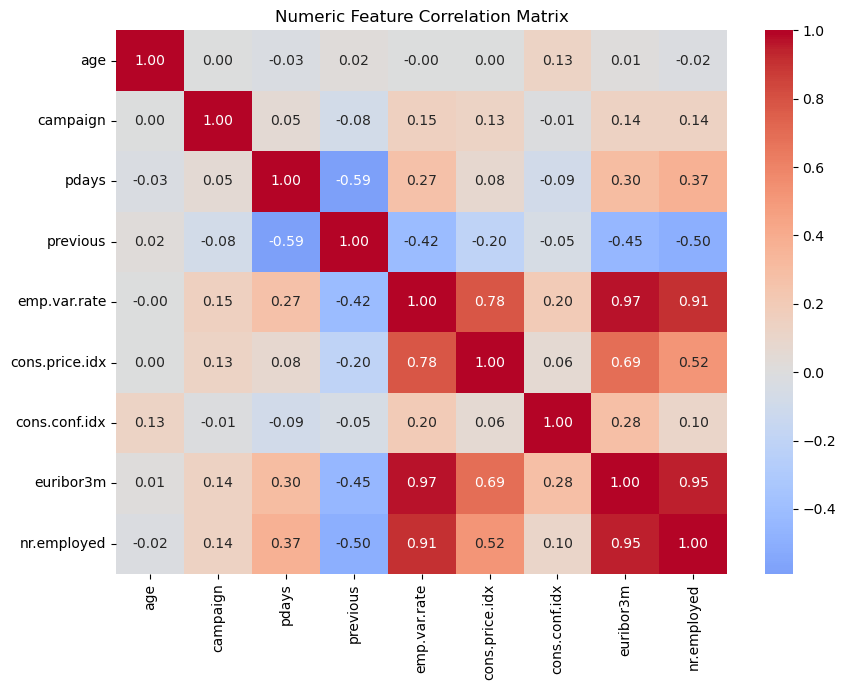

In [6]:
# Feature lists
numeric_features_bank = ['age', 'campaign', 'pdays', 'previous','emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
categorical_features_bank = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

# Preprocessing pipelines
numeric_transformer_bank = Pipeline([
    ('scaler', StandardScaler())
])
categorical_transformer_bank = Pipeline([
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))  # dense output required by QDA/Naive Bayes
])
preprocessor_bank = ColumnTransformer([
    ('num', numeric_transformer_bank, numeric_features_bank),
    ('cat', categorical_transformer_bank, categorical_features_bank)
])

# Multicollinearity check — relevant for QDA's covariance matrix inversion
corr_matrix = df_bank[numeric_features_bank].corr().round(2)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax)
ax.set_title('Numeric Feature Correlation Matrix')
plt.tight_layout()
plt.show()

**Result:** the economic indicators form a clear severe collinearity 
cluster — `emp.var.rate`, `euribor3m`, and `nr.employed` correlate 
at 0.91–0.97 (|r| > 0.9), with `cons.price.idx` moderately involved 
(0.69–0.78). `pdays` and `previous` also show moderate negative 
correlation (−0.59), and `previous` correlates moderately with 
several economic indicators (−0.42 to −0.50) — not severe enough to 
cause matrix inversion failure, but worth keeping in mind during 
interpretation. `reg_param` stabilizes QDA's covariance matrix for 
the severe cluster specifically; its value is chosen next by sweeping 
a small range and scoring by F2.

In [7]:
X_bank = df_bank[numeric_features_bank + categorical_features_bank]
y_bank = (df_bank['y'] == 'yes').astype(int)

f2_scorer = make_scorer(fbeta_score, beta=2)

skf_bank = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for rp in [0.01, 0.1, 0.3, 0.5]:
    qda_pipeline = Pipeline([
        ('preprocessor', preprocessor_bank),
        ('model', QuadraticDiscriminantAnalysis(reg_param=rp))
    ])
    cv = cross_validate(qda_pipeline, X_bank, y_bank, cv=skf_bank, scoring=f2_scorer)
    print(f"reg_param={rp}: F2={cv['test_score'].mean():.4f}")

reg_param=0.01: F2=0.4964
reg_param=0.1: F2=0.4586
reg_param=0.3: F2=0.4481
reg_param=0.5: F2=0.4444


**Result:** `reg_param=0.01` gives the highest F2 (0.4964); 
performance drops with each increase in regularization. 
QDA uses `reg_param=0.01` throughout the comparison.

## Model Comparison

Six configurations compared using 5-fold stratified cross-validation, 
scored by F2, with accuracy, precision, recall, F1, and 
training time reported for reference. All models share the same 
preprocessor and CV splits.

In [8]:
scoring = {
    'accuracy': 'accuracy',
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1',
    'f2': f2_scorer
}

models_bank = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Logistic Regression (weighted)': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(reg_param=0.01),  # regularized for collinearity
    'Naive Bayes': GaussianNB(),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42),
}

results_bank = []
for name, model in models_bank.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor_bank),
        ('model', model)
        ])
    start = time.time()
    cv = cross_validate(pipeline, X_bank, y_bank, cv=skf_bank, scoring=scoring)
    elapsed = time.time() - start
    results_bank.append({
        'Method': name,
        'Accuracy': cv['test_accuracy'].mean(),
        'Recall': cv['test_recall'].mean(),
        'Precision': cv['test_precision'].mean(),
        'F1': cv['test_f1'].mean(),
        'F2': cv['test_f2'].mean(),
        'Time (s)': round(elapsed, 1)
    })
    print(f"{name}: done in {elapsed:.1f}s")

results_bank_df = pd.DataFrame(results_bank).round(4)
print(results_bank_df)

Logistic Regression: done in 2.0s
Logistic Regression (weighted): done in 1.9s
LDA: done in 1.3s
QDA: done in 1.1s
Naive Bayes: done in 0.8s
SVM (RBF): done in 439.1s
                           Method  Accuracy  Recall  Precision      F1  \
0             Logistic Regression    0.9000  0.2297     0.6599  0.3402   
1  Logistic Regression (weighted)    0.8276  0.6284     0.3517  0.4509   
2                             LDA    0.8900  0.3765     0.5166  0.4353   
3                             QDA    0.8694  0.5153     0.4332  0.4706   
4                     Naive Bayes    0.8255  0.5528     0.3341  0.4164   
5                       SVM (RBF)    0.9012  0.2515     0.6617  0.3639   

       F2  Time (s)  
0  0.2640       2.0  
1  0.5429       1.9  
2  0.3980       1.3  
3  0.4964       1.1  
4  0.4887       0.8  
5  0.2869     439.1  


## Model Comparison — Results

| Method | Accuracy | Recall | Precision | F1 | F2 | Time (s) |
|---|---|---|---|---|---|---|
| LR (unweighted) | 0.9000 | 0.2297 | 0.6599 | 0.3402 | 0.2640 | 2.0 |
| LR (weighted) | 0.8276 | 0.6284 | 0.3517 | 0.4509 | 0.5429 | 1.9 |
| LDA | 0.8900 | 0.3765 | 0.5166 | 0.4353 | 0.3980 | 1.3 |
| QDA | 0.8694 | 0.5153 | 0.4332 | 0.4706 | 0.4964 | 1.0 |
| Naive Bayes | 0.8255 | 0.5528 | 0.3341 | 0.4164 | 0.4887 | 0.8 |
| SVM (RBF) | 0.9012 | 0.2515 | 0.6617 | 0.3639 | 0.2869 | 394.4 |

**Result:** the metric decides the winner.

Unweighted Logistic Regression makes the point plainly: F1 puts it 
mid-table (0.3402), F2 puts it last (0.2640). Add class weighting 
and it flips to first — weighted Logistic Regression leads the entire 
comparison by F2 (0.5429) in under 2 seconds. This is why metric choice matters in imbalanced classification.

QDA (0.4964) and Naive Bayes (0.4887) follow. SVM finishes last by 
F2 (0.2869) at 394 seconds — excluded from further tuning; a 2-second 
model already outperforms it by a wide margin.

All rankings use the default 0.5 threshold. XGBoost and threshold 
optimization follow — the final ranking may shift again.

## Adding XGBoost

The six methods compared so far each rely on an explicit assumption 
about the data — a linear boundary, shared or per-class covariance, 
feature independence. XGBoost makes none of these. It's included here 
specifically to test whether a flexible, assumption-free model beats 
the assumption-based ones, and unlike the others, it's tuned rather 
than run on defaults: n_estimators, max_depth, learning_rate, and 
subsample searched via RandomizedSearchCV, scored directly on F2.

In [9]:
xgb_pipeline_bank = Pipeline([
    ('preprocessor', preprocessor_bank),
    ('model', XGBClassifier(random_state=42, eval_metric='logloss'))
])

param_dist = {
    'model__n_estimators': [50, 100, 200, 300],
    'model__max_depth': [2, 3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.3],
    'model__subsample': [0.7, 0.85, 1.0]
}

random_search_xgb = RandomizedSearchCV(
    xgb_pipeline_bank,
    param_distributions=param_dist,
    n_iter=25,
    cv=skf_bank,
    scoring=f2_scorer,
    random_state=42,
    n_jobs=-1
)

start = time.time()
random_search_xgb.fit(X_bank, y_bank)
xgb_search_time = time.time() - start
print(f"Search time: {xgb_search_time:.1f}s")
print(random_search_xgb.best_params_)

# Full metric evaluation on best model
best_xgb_pipeline = random_search_xgb.best_estimator_
start = time.time()
cv_xgb_full = cross_validate(
    best_xgb_pipeline, X_bank, y_bank, cv=skf_bank,
    scoring={'accuracy': 'accuracy', 'recall': 'recall',
             'precision': 'precision', 'f1': 'f1', 'f2': f2_scorer}
)
xgb_cv_time = time.time() - start

print(f"XGBoost (tuned): "
      f"accuracy={cv_xgb_full['test_accuracy'].mean():.4f}, "
      f"recall={cv_xgb_full['test_recall'].mean():.4f}, "
      f"precision={cv_xgb_full['test_precision'].mean():.4f}, "
      f"f1={cv_xgb_full['test_f1'].mean():.4f}, "
      f"f2={cv_xgb_full['test_f2'].mean():.4f}, "
      f"cv={xgb_cv_time:.1f}s")

Search time: 38.8s
{'model__subsample': 0.7, 'model__n_estimators': 300, 'model__max_depth': 5, 'model__learning_rate': 0.3}
XGBoost (tuned): accuracy=0.8950, recall=0.3009, precision=0.5634, f1=0.3922, f2=0.3318, cv=5.6s


**Result:** best params: n_estimators=300, max_depth=5, 
learning_rate=0.3, subsample=0.7 (search: 35.6s, CV: 5.2s).

XGBoost (tuned): F2=0.3318 — below weighted Logistic Regression 
(0.5429), QDA (0.4964), and Naive Bayes (0.4887). Hyperparameter 
tuning alone, without addressing class imbalance, is not enough.

## XGBoost — Class-Weighted Variant

The tuned XGBoost above optimized hyperparameters but left class 
imbalance uncorrected. This variant takes the opposite approach: 
default hyperparameters, but with `scale_pos_weight` set to the 
negative-to-positive class ratio, penalizing missed subscribers 
more heavily during training itself.

In [10]:
xgb_pipeline_weighted = Pipeline([
    ('preprocessor', preprocessor_bank),
    ('model', XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        scale_pos_weight=(y_bank == 0).sum() / (y_bank == 1).sum()
    ))
])

start = time.time()
cv_xgb_weighted = cross_validate(
    xgb_pipeline_weighted, X_bank, y_bank, cv=skf_bank,
    scoring={'accuracy': 'accuracy', 'recall': 'recall',
             'precision': 'precision', 'f1': 'f1', 'f2': f2_scorer}
)
xgb_weighted_time = time.time() - start

print(f"scale_pos_weight: {(y_bank==0).sum()/(y_bank==1).sum():.3f}")
print(f"XGBoost (weighted): "
      f"accuracy={cv_xgb_weighted['test_accuracy'].mean():.4f}, "
      f"recall={cv_xgb_weighted['test_recall'].mean():.4f}, "
      f"precision={cv_xgb_weighted['test_precision'].mean():.4f}, "
      f"f1={cv_xgb_weighted['test_f1'].mean():.4f}, "
      f"f2={cv_xgb_weighted['test_f2'].mean():.4f}, "
      f"time={xgb_weighted_time:.1f}s")

scale_pos_weight: 7.877
XGBoost (weighted): accuracy=0.8369, recall=0.5834, precision=0.3614, f1=0.4463, f2=0.5195, time=3.1s


**Result:** scale_pos_weight=7.877 (36,548 non-subscribers / 4,640 
subscribers) — tells XGBoost to penalize missed subscribers ~8x 
more heavily than missed non-subscribers during training, directly 
reflecting the class imbalance.

XGBoost (weighted): F2=0.5195 in 2.6s — second in the comparison 
so far, behind weighted Logistic Regression (0.5429). 

At default threshold, addressing class imbalance via `scale_pos_weight` adds 
more value than hyperparameter tuning alone — though a fair comparison would tune both.

## Full Comparison — All Eight Configurations

| Method | Accuracy | Recall | Precision | F1 | F2 | Time (s) |
|---|---|---|---|---|---|---|
| LR (unweighted) | 0.9000 | 0.2297 | 0.6599 | 0.3402 | 0.2640 | 2.0 |
| **LR (weighted)** | 0.8276 | 0.6284 | 0.3517 | 0.4509 | **0.5429** | 1.9 |
| LDA | 0.8900 | 0.3765 | 0.5166 | 0.4353 | 0.3980 | 1.3 |
| QDA | 0.8694 | 0.5153 | 0.4332 | 0.4706 | 0.4964 | 1.0 |
| Naive Bayes | 0.8255 | 0.5528 | 0.3341 | 0.4164 | 0.4887 | 0.8 |
| SVM (RBF) | 0.9012 | 0.2515 | 0.6617 | 0.3639 | 0.2869 | 394.4 |
| XGBoost (tuned) | 0.8950 | 0.3009 | 0.5634 | 0.3922 | 0.3318 | 5.2 |
| XGBoost (weighted) | 0.8369 | 0.5834 | 0.3614 | 0.4463 | 0.5195 | 2.6 |

**Result:** at default threshold (0.5), weighted Logistic Regression 
leads by F2 (0.5429) — the metric that reflects the actual cost 
of this problem. It trains in under 2 seconds.

The F1 column tells a different story: unweighted Logistic Regression 
sits mid-table by F1 (0.3402) but last by F2 (0.2640); weighted LR 
is mid-table by F1 (0.4509) but first by F2 (0.5429). The ranking 
reversal is not noise — it is what happens when the metric matches 
the business problem.

XGBoost (weighted) sits second by F2 (0.5195) despite using only 
default hyperparameters, outperforming the fully tuned unweighted 
variant (F2=0.3318). SVM ranks last by F2 (0.2869) 
at 394 seconds — excluded from further analysis.

These are default-threshold results. Threshold optimization follows 
— the final ranking may shift.

## Threshold Optimization

The default 0.5 threshold is arbitrary. Since missing a subscriber 
likely costs more than a wasted call, a lower threshold may serve the 
business better - checked directly here using out-of-fold predicted 
probabilities, rather than assumed. SVM is excluded: last by F2 at 
default threshold, 394 seconds to train.

In [11]:
def f2_optimal_threshold(y_true, y_proba, beta=2):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f2_scores = (1 + beta**2) * (precisions[:-1] * recalls[:-1]) / (
                 beta**2 * precisions[:-1] + recalls[:-1] + 1e-12)
    best_idx = np.argmax(f2_scores)
    return thresholds[best_idx], f2_scores[best_idx]

results_threshold = []

# Statistical models — exclude SVM
for name, model in models_bank.items():
    if name == 'SVM (RBF)':
        continue
    pipeline = Pipeline([('preprocessor', preprocessor_bank), ('model', model)])
    y_proba = cross_val_predict(pipeline, X_bank, y_bank,
                                cv=skf_bank, method='predict_proba')[:, 1]
    default_f2 = fbeta_score(y_bank, (y_proba >= 0.5).astype(int), beta=2)
    best_thresh, best_f2 = f2_optimal_threshold(y_bank, y_proba)
    print(f"{name}: default={default_f2:.4f} → optimal={best_f2:.4f} "
          f"(threshold={best_thresh:.4f})")
    results_threshold.append({'Model': name, 'Default F2': default_f2,
                              'Optimal Threshold': best_thresh,
                              'Optimal F2': best_f2, 'y_proba': y_proba})

# XGBoost variants
for name, pipeline in [('XGBoost (tuned)', best_xgb_pipeline),
                        ('XGBoost (weighted)', xgb_pipeline_weighted)]:
    y_proba = cross_val_predict(pipeline, X_bank, y_bank,
                                cv=skf_bank, method='predict_proba')[:, 1]
    default_f2 = fbeta_score(y_bank, (y_proba >= 0.5).astype(int), beta=2)
    best_thresh, best_f2 = f2_optimal_threshold(y_bank, y_proba)
    print(f"{name}: default={default_f2:.4f} → optimal={best_f2:.4f} "
          f"(threshold={best_thresh:.4f})")
    results_threshold.append({'Model': name, 'Default F2': default_f2,
                              'Optimal Threshold': best_thresh,
                              'Optimal F2': best_f2, 'y_proba': y_proba})

Logistic Regression: default=0.2642 → optimal=0.5458 (threshold=0.1347)
Logistic Regression (weighted): default=0.5430 → optimal=0.5450 (threshold=0.5442)
LDA: default=0.3981 → optimal=0.5456 (threshold=0.0925)
QDA: default=0.4964 → optimal=0.5424 (threshold=0.0017)
Naive Bayes: default=0.4888 → optimal=0.5177 (threshold=0.0325)
XGBoost (tuned): default=0.3318 → optimal=0.5151 (threshold=0.1050)
XGBoost (weighted): default=0.5195 → optimal=0.5225 (threshold=0.4460)


## Final Model Selection

| Model | Optimal F2 | Threshold |
|---|---|---|
| LR (unweighted) | 0.5458 | 0.1347 |
| LDA | 0.5456 | 0.0925 |
| LR (weighted) | 0.5450 | 0.5442 |
| QDA | 0.5424 | 0.0017 |
| Naive Bayes | 0.5177 | 0.0325 |
| XGBoost (weighted) | 0.5225 | 0.4460 |
| XGBoost (tuned) | 0.5151 | 0.1050 |

After threshold tuning, Logistic Regression (unweighted and weighted), 
LDA, and QDA all land at a similar F2 score, close enough that F2 
alone doesn't give a clear winner.

**Going with Logistic Regression (unweighted), threshold=0.1347.**

The reasoning is about assumptions, not the score. LDA and QDA both 
assume the features are roughly Gaussian within each class - but this 
dataset has heavily collinear economic indicators and one-hot encoded 
categorical columns, neither of which look anything like a Gaussian. 
Logistic Regression doesn't make that assumption, so it's the safer 
bet given what we actually know about this data.

Weighted and unweighted LR land on almost the same result after 
threshold tuning - the weighting adds basically nothing once the 
threshold is optimized. Zhao (2008) found the same pattern for 
logistic regression specifically, where weighting and threshold 
adjustment converge, while tree-based models tend to diverge more.

For a Belgian bank, being able to explain individual predictions isn't optional. Logistic 
Regression's coefficients are directly interpretable, and its 
probabilities are well-calibrated.

**Reference**

Zhao, H. (2008). Instance weighting versus threshold adjusting for 
cost-sensitive classification. *Knowledge and Information Systems*, 
15(3), 321-334. https://doi.org/10.1007/s10115-007-0079-1

## SHAP on the Winning Model (Logistic Regression)

Logistic Regression uses `LinearExplainer`, which computes exact 
SHAP values for all 41,188 rows directly from the model's 
coefficients - no row sampling. A background set of 100 rows is 
used internally to estimate feature correlation, the standard 
default for this explainer.

Background dataset has 41188 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=41188 when initializing the masker.


Done. shap_values shape: (41188, 52)


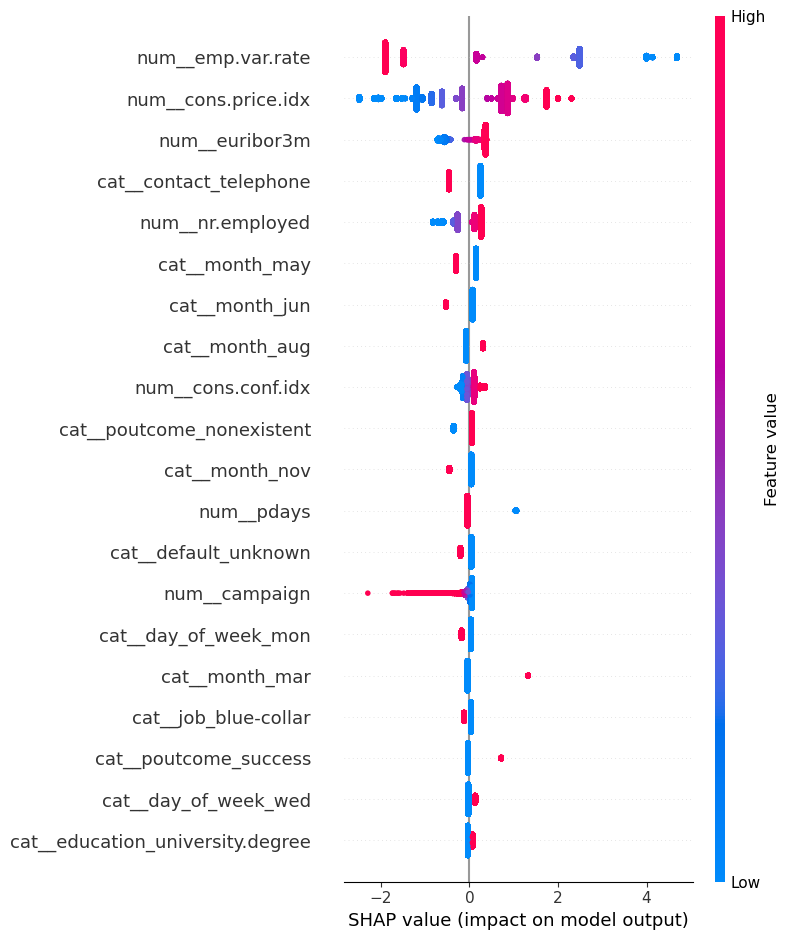

In [12]:
# Fit the final, winning model on the full dataset
final_pipeline = Pipeline([
    ('preprocessor', preprocessor_bank),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])
final_pipeline.fit(X_bank, y_bank)

# Transform data once, since SHAP needs the model's actual numeric input, not raw features
X_bank_transformed = final_pipeline.named_steps['preprocessor'].transform(X_bank)
feature_names = final_pipeline.named_steps['preprocessor'].get_feature_names_out()
lr_model = final_pipeline.named_steps['model']

# LinearExplainer computes exact SHAP values for all rows;
# background set for correlation estimation defaults to 100 samples
explainer = shap.LinearExplainer(lr_model, X_bank_transformed)
shap_values = explainer.shap_values(X_bank_transformed)

print("Done. shap_values shape:", np.array(shap_values).shape)
shap.summary_plot(shap_values, X_bank_transformed, feature_names=feature_names)

## SHAP — Global Feature Importance

**Result:** economic indicators dominate — `emp.var.rate`, 
`cons.price.idx`, and `euribor3m` top the ranking, reflecting timing 
the bank doesn't control rather than client-specific traits.

`contact_telephone` is the strongest actionable feature: landline 
contact correlates with lower subscription probability than cellular. 
`campaign` shows a similar actionable pattern — most clients cluster 
near zero impact, but heavily-contacted clients get pushed toward 
"no," suggesting fewer repeated attempts may help. `poutcome_success` 
still shows a positive effect, though modest relative to the top 
features.

Overall, the model leans on timing the bank can't control; contact 
method and contact frequency are the clearest levers it can actually 
use.

## SHAP — A Local Explanation

Beyond the global pattern, SHAP can explain a single prediction — 
useful for a real business question like "why did the model flag this 
specific client as a likely subscriber." One high-probability and one 
low-probability client from the full dataset are shown below.

In [13]:
# Get predicted probabilities from the final Logistic Regression model
lr_proba = final_pipeline.predict_proba(X_bank)[:, 1]

# Highest and lowest probability clients
high_idx = np.argmax(lr_proba)
low_idx = np.argmin(lr_proba)

print(f"Highest probability client: index={high_idx}, proba={lr_proba[high_idx]:.4f}")
print(f"Lowest probability client: index={low_idx}, proba={lr_proba[low_idx]:.4f}")

Highest probability client: index=40373, proba=0.8982
Lowest probability client: index=4107, proba=0.0026


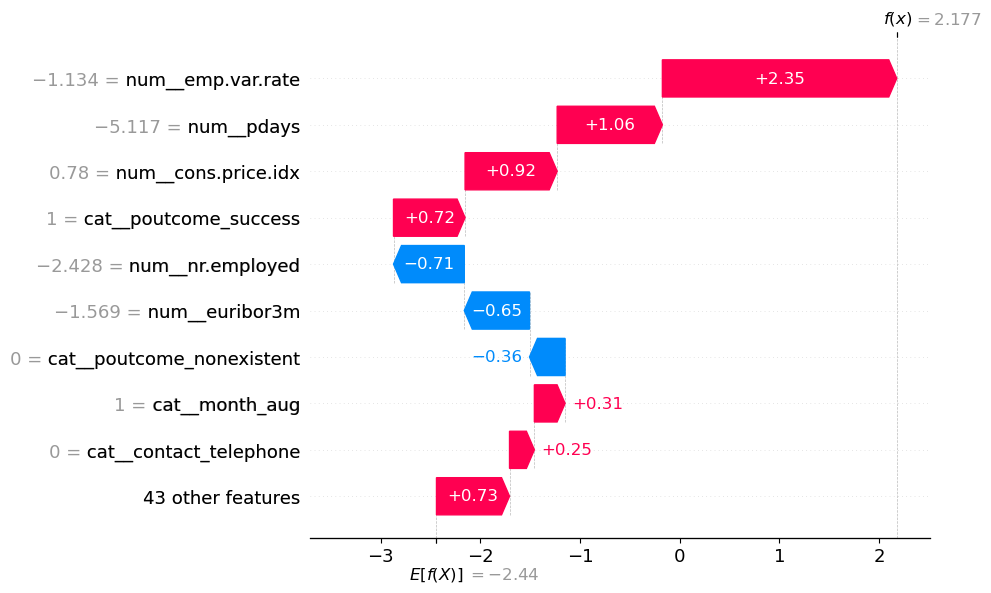

In [14]:
# Waterfall plot for the highest-probability client
shap.plots.waterfall(shap.Explanation(
    values=shap_values[high_idx],
    base_values=explainer.expected_value,
    data=X_bank_transformed[high_idx],
    feature_names=feature_names
))

**Result:** for the highest-probability client (proba=0.8982), the 
strongest driver is economic timing (`emp.var.rate`, +2.35) - 
consistent with the global pattern. But this client also has a real, 
client-specific reason to be flagged: `poutcome_success=1` (+0.72) - 
they subscribed in a previous campaign, and were recontacted quickly 
(`pdays=6`, +1.06). This is a concrete example of the "target past 
successful subscribers" recommendation from the global SHAP results, 
grounded in one real client rather than an aggregate pattern.

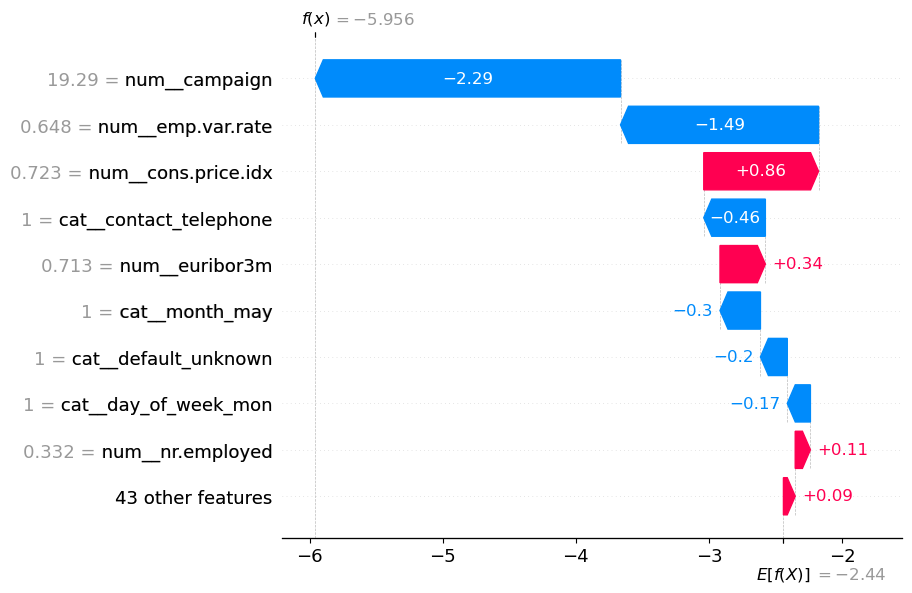

In [15]:
# Waterfall plot for the lowest-probability client
shap.plots.waterfall(shap.Explanation(
    values=shap_values[low_idx],
    base_values=explainer.expected_value,
    data=X_bank_transformed[low_idx],
    feature_names=feature_names
))

**Result:** for the lowest-probability client (proba≈0.003), the 
single largest driver is `campaign` (contact frequency) - an 
extremely high number of contact attempts for this client pushes the 
prediction sharply toward "no," by far the biggest single contribution 
seen in either waterfall plot. Economic timing plays a smaller, mixed 
role here compared to the high-probability client. This gives a 
concrete example of the "high contact counts hurt" pattern from the 
global SHAP results: excessive recontacting is not just a general 
trend, it visibly dominates the prediction for an individual client.

## Feature Importance

Our project finds that economic/social indicators as a group 
outweigh individual client attributes - consistent with Moro et al.'s 
broader conclusion, even though a feature-by-feature comparison isn't 
possible given the different dataset and method used here. This 
project works from a public dataset with a practical, scoped 
workflow; a fuller comparison would require running the same 
importance method on the same features.

## Business Recommendation

**Operating point:** rather than a strict, cautious cutoff, this campaign deliberately sets a lower bar for "call this client" — catching more of the people who would say yes, even though it also means calling some who say no. The idea is simple: missing someone who would have subscribed is a real lost sale, while an extra call that doesn't convert only costs a few minutes of staff time. So the approach leans toward calling more people, not fewer, whenever there's doubt.

**Three concrete, actionable levers — separate from the model's predictions themselves:**

1. **Prioritize cellular contact over landline.** SHAP results show landline contact is associated with lower subscription probability than cellular, holding other factors constant. Where the bank has a choice of contact method on file, cellular should be preferred.

2. **Cap the number of contact attempts per client.** Both the global SHAP pattern and the low-probability client example show that heavy recontacting correlates with lower, not higher, conversion. A policy limiting attempts per client within a campaign — rather than calling until someone answers or gives up — is supported directly by this data.

3. **Re-prioritize clients with a successful previous campaign outcome.** `poutcome_success` is a real, positive, client-specific driver in both the global and local SHAP results. This is a client segment the bank already has on record and can act on directly, independent of current economic conditions.

**What the model is not useful for:** the dominant predictors — `emp.var.rate`, `cons.price.idx`, `euribor3m` — describe the broader economic climate, not the client. This means the model is best used as a **current-conditions prioritization tool** (who to call given today's economic environment), not a fixed, static targeting list. As the economic climate shifts, which clients the model favors will shift too, independent of anything about those clients changing.

**Before full deployment, two things should happen, not be skipped:**

- **A staged rollout with outcome monitoring**, not an immediate full-scale switch. Reported performance here comes from in-sample evaluation rather than a genuine out-of-time test, so real forward-looking performance could differ from what's reported here. A pilot campaign, with outcomes tracked against the model's predictions, would confirm this before broader rollout.
- **A defined re-training cadence.** Given how much weight the model places on time-varying economic indicators, its predictions will degrade as the economic climate moves away from the training period (2008–2010) — this is not a one-time model, and should be refreshed with recent data on a regular schedule, not deployed once and left running.

**Interpretability as a compliance asset, not just a technical nicety:** Logistic Regression was selected in part because its coefficients are directly interpretable — for a Belgian bank operating under GDPR and the EU AI Act, this means any individual client's flagging decision can be explained in plain terms if required, without needing a separate post-hoc explanation layer.